In [78]:
import pandas as pd
import plotly.express as px
import streamlit as st

df=pd.read_csv('patients_sample_500.csv')
df.head()

,patient_id,admission_date,discharge_date,department,doctor,age,gender,diagnosis,admission_type,insurance_type,revenue,cost,satisfaction_score,readmission_flag,death_flag
0,1,2025-04-13,2025-04-17,Neurology,Dr_7,83,Male,Heart Failure,Routine,Social Security,1360,668,3.4,0,0
1,2,2025-09-15,2025-09-23,Internal Medicine,Dr_1,76,Female,Infection,Emergency,Social Security,7449,2982,2.2,0,0
2,3,2025-07-07,2025-07-21,Internal Medicine,Dr_20,64,Male,Heart Failure,Routine,Armed Forces,3234,2293,1.7,0,0
3,4,2025-11-12,2025-11-26,Cardiology,Dr_2,84,Female,Stroke,Emergency,Social Security,8933,5294,4.3,0,0
4,5,2025-02-19,2025-02-27,Orthopedics,Dr_10,4,Female,Fracture,Routine,Private,8055,4477,2.8,0,0


In [79]:
print(df["admission_date"])

0      2025-04-13
1      2025-09-15
2      2025-07-07
3      2025-11-12
4      2025-02-19
          ...    
495    2025-10-25
496    2025-09-09
497    2025-01-03
498    2025-02-21
499    2025-12-23
Name: admission_date, Length: 500, dtype: object


In [80]:
df["admission_date"]=pd.to_datetime(df["admission_date"])
print(df["admission_date"])

0     2025-04-13
1     2025-09-15
2     2025-07-07
3     2025-11-12
4     2025-02-19
         ...    
495   2025-10-25
496   2025-09-09
497   2025-01-03
498   2025-02-21
499   2025-12-23
Name: admission_date, Length: 500, dtype: datetime64[ns]


In [81]:
print(df["discharge_date"])

0      2025-04-17
1      2025-09-23
2      2025-07-21
3      2025-11-26
4      2025-02-27
          ...    
495    2025-10-31
496    2025-09-20
497    2025-01-09
498    2025-02-27
499    2025-12-31
Name: discharge_date, Length: 500, dtype: object


In [82]:
df["discharge_date"]=pd.to_datetime(df["discharge_date"])
print(df["discharge_date"])

0     2025-04-17
1     2025-09-23
2     2025-07-21
3     2025-11-26
4     2025-02-27
         ...    
495   2025-10-31
496   2025-09-20
497   2025-01-09
498   2025-02-27
499   2025-12-31
Name: discharge_date, Length: 500, dtype: datetime64[ns]


In [83]:
df["length_of_stay"]=(df["discharge_date"]-df["admission_date"]).dt.days
df.head()

,patient_id,admission_date,discharge_date,department,doctor,age,gender,diagnosis,admission_type,insurance_type,revenue,cost,satisfaction_score,readmission_flag,death_flag,length_of_stay
0,1,2025-04-13,2025-04-17,Neurology,Dr_7,83,Male,Heart Failure,Routine,Social Security,1360,668,3.4,0,0,4
1,2,2025-09-15,2025-09-23,Internal Medicine,Dr_1,76,Female,Infection,Emergency,Social Security,7449,2982,2.2,0,0,8
2,3,2025-07-07,2025-07-21,Internal Medicine,Dr_20,64,Male,Heart Failure,Routine,Armed Forces,3234,2293,1.7,0,0,14
3,4,2025-11-12,2025-11-26,Cardiology,Dr_2,84,Female,Stroke,Emergency,Social Security,8933,5294,4.3,0,0,14
4,5,2025-02-19,2025-02-27,Orthopedics,Dr_10,4,Female,Fracture,Routine,Private,8055,4477,2.8,0,0,8


In [84]:
print(df.shape)

(500, 16)


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patient_id          500 non-null    int64         
 1   admission_date      500 non-null    datetime64[ns]
 2   discharge_date      500 non-null    datetime64[ns]
 3   department          500 non-null    object        
 4   doctor              500 non-null    object        
 5   age                 500 non-null    int64         
 6   gender              500 non-null    object        
 7   diagnosis           500 non-null    object        
 8   admission_type      500 non-null    object        
 9   insurance_type      369 non-null    object        
 10  revenue             500 non-null    int64         
 11  cost                500 non-null    int64         
 12  satisfaction_score  500 non-null    float64       
 13  readmission_flag    500 non-null    int64         

In [86]:
df.describe()

,patient_id,admission_date,discharge_date,age,revenue,cost,satisfaction_score,readmission_flag,death_flag,length_of_stay
count,500.000000,500,500,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2025-06-27 10:19:11.999999744,2025-07-04 23:42:43.200000,47.216000,5252.66200,3385.766000,3.052000,0.092000,0.016000,7.558000
min,1.000000,2025-01-01 00:00:00,2025-01-06 00:00:00,1.000000,509.00000,246.000000,1.000000,0.000000,0.000000,1.000000
25%,125.750000,2025-03-23 00:00:00,2025-03-30 18:00:00,23.750000,2976.50000,1720.000000,2.000000,0.000000,0.000000,4.000000
50%,250.500000,2025-07-02 00:00:00,2025-07-08 00:00:00,47.500000,5270.00000,3224.500000,3.100000,0.000000,0.000000,7.000000
75%,375.250000,2025-09-28 06:00:00,2025-10-01 12:00:00,69.000000,7666.00000,4849.750000,4.100000,0.000000,0.000000,11.000000
max,500.000000,2025-12-31 00:00:00,2026-01-10 00:00:00,94.000000,9980.00000,8471.000000,5.000000,1.000000,1.000000,14.000000
std,144.481833,NaN,NaN,27.496645,2733.17158,1949.472912,1.180153,0.289315,0.125601,3.958532


In [87]:
df.isnull().sum()

patient_id              0
admission_date          0
discharge_date          0
department              0
doctor                  0
age                     0
gender                  0
diagnosis               0
admission_type          0
insurance_type        131
revenue                 0
cost                    0
satisfaction_score      0
readmission_flag        0
death_flag              0
length_of_stay          0
dtype: int64

In [88]:
alos=df["length_of_stay"].mean()
print(f"average length of stay = {alos:.2f} days")

average length of stay = 7.56 days


In [89]:
df[df["insurance_type"].isnull()].head()

,patient_id,admission_date,discharge_date,department,doctor,age,gender,diagnosis,admission_type,insurance_type,revenue,cost,satisfaction_score,readmission_flag,death_flag,length_of_stay
6,7,2025-02-10,2025-02-23,ICU,Dr_7,9,Female,Hypertension,Emergency,NaN,2562,1236,1.1,0,0,13
9,10,2025-12-25,2026-01-05,Cardiology,Dr_10,77,Male,Hypertension,Emergency,NaN,4988,3767,3.8,0,0,11
13,14,2025-04-23,2025-05-07,Orthopedics,Dr_7,2,Male,Hypertension,Emergency,NaN,7085,6243,1.1,0,0,14
15,16,2025-05-03,2025-05-04,Neurology,Dr_20,70,Female,Heart Failure,Routine,NaN,9458,7581,4.3,0,0,1
20,21,2025-12-04,2025-12-06,Neurology,Dr_9,33,Female,Hypertension,Routine,NaN,3369,2102,4.0,0,0,2


In [90]:
missing_percent=(df.isnull().sum()/len(df))
print(f"missing_percent=\n {missing_percent}")

missing_percent=
 patient_id            0.000
admission_date        0.000
discharge_date        0.000
department            0.000
doctor                0.000
age                   0.000
gender                0.000
diagnosis             0.000
admission_type        0.000
insurance_type        0.262
revenue               0.000
cost                  0.000
satisfaction_score    0.000
readmission_flag      0.000
death_flag            0.000
length_of_stay        0.000
dtype: float64


In [91]:
df_fill = df.copy()

In [92]:
df_fill["insurance_type"]=df_fill["insurance_type"].fillna("unknown")


In [93]:
df_fill["insurance_type"].value_counts()

insurance_type
Social Security    133
unknown            131
Private            121
Armed Forces       115
Name: count, dtype: int64

In [94]:
readmission_rate_fill =(df_fill["readmission_flag"].mean())*100
print(f"readmission rate fill = {readmission_rate_fill :.2f}%")

readmission rate fill = 9.20%


In [95]:
mortality_rate_fill=(df_fill["death_flag"].mean())*100
print(f"mortality rate fill = {mortality_rate_fill:.2f}%")

mortality rate fill = 1.60%


In [96]:
alos_fill=df_fill["length_of_stay"].mean()
print(f"average length of stay fill = {alos:.2f} days")

average length of stay fill = 7.56 days


In [97]:
total_patients=len(df)
print(f"total patients = {total_patients}")

total patients = 500


In [98]:
total_revenue=df["revenue"].sum()
print(f"total revenue = {total_revenue}")

total revenue = 2626331


In [99]:
total_cost=df["cost"].sum()
print(f"total cost = {total_cost}")

total cost = 1692883


In [100]:
profit=total_revenue-total_cost
print(f"profit = {profit}")

profit = 933448


In [101]:
revenue_per_patient=total_revenue/total_patients
print(f"revenue per patient = {revenue_per_patient}")

revenue per patient = 5252.662


In [102]:
profit_margin=(profit/total_revenue)*100
print(f"profit margin = {profit_margin}")

profit margin = 35.54190237254938


In [103]:
department_summary=(df.groupby("department").agg({"patient_id":"count",
                                                  "revenue":"sum","cost":"sum",
                                                  "length_of_stay":"mean",
                                                  "readmission_flag":"mean",
                                                  "death_flag":"mean"}))
print("department summary :",department_summary)

department summary :                    patient_id  revenue    cost  length_of_stay  \
department                                                       
Cardiology                 96   511685  334831        7.895833   
ICU                        81   411625  253158        7.530864   
Internal Medicine          77   378904  238061        6.818182   
Neurology                  82   454884  302170        7.414634   
Orthopedics                89   477438  309111        7.831461   
Surgery                    75   391795  255552        7.746667   

                   readmission_flag  death_flag  
department                                       
Cardiology                 0.083333    0.010417  
ICU                        0.098765    0.012346  
Internal Medicine          0.103896    0.025974  
Neurology                  0.134146    0.012195  
Orthopedics                0.033708    0.011236  
Surgery                    0.106667    0.026667  


In [104]:
department_summary=department_summary.rename(columns={
        "patient_id":"patients",
        "revenue":"revenue",
        "cost":"cost",
        "length_of_stay":"alos",
        "readmission_flag":"readmission_rate",
        "death_flag":"mortality_rate"
    }
)
print("department summary :",department_summary)

department summary :                    patients  revenue    cost      alos  readmission_rate  \
department                                                                 
Cardiology               96   511685  334831  7.895833          0.083333   
ICU                      81   411625  253158  7.530864          0.098765   
Internal Medicine        77   378904  238061  6.818182          0.103896   
Neurology                82   454884  302170  7.414634          0.134146   
Orthopedics              89   477438  309111  7.831461          0.033708   
Surgery                  75   391795  255552  7.746667          0.106667   

                   mortality_rate  
department                         
Cardiology               0.010417  
ICU                      0.012346  
Internal Medicine        0.025974  
Neurology                0.012195  
Orthopedics              0.011236  
Surgery                  0.026667  


In [105]:
department_summary["profit"] = (
    department_summary["revenue"]
    -
    department_summary["cost"]
)
print("department_summary_profit: ",department_summary)
print("===============================================================================================")
print("department_summary_profit: ",department_summary["profit"])

department_summary_profit:                     patients  revenue    cost      alos  readmission_rate  \
department                                                                 
Cardiology               96   511685  334831  7.895833          0.083333   
ICU                      81   411625  253158  7.530864          0.098765   
Internal Medicine        77   378904  238061  6.818182          0.103896   
Neurology                82   454884  302170  7.414634          0.134146   
Orthopedics              89   477438  309111  7.831461          0.033708   
Surgery                  75   391795  255552  7.746667          0.106667   

                   mortality_rate  profit  
department                                 
Cardiology               0.010417  176854  
ICU                      0.012346  158467  
Internal Medicine        0.025974  140843  
Neurology                0.012195  152714  
Orthopedics              0.011236  168327  
Surgery                  0.026667  136243  
department_

In [106]:
department_summary["readmission_rate"] *= 100

department_summary["mortality_rate"] *= 100

department_summary


,patients,revenue,cost,alos,readmission_rate,mortality_rate,profit
department,,,,,,,
Cardiology,96,511685,334831,7.895833,8.333333,1.041667,176854
ICU,81,411625,253158,7.530864,9.876543,1.234568,158467
Internal Medicine,77,378904,238061,6.818182,10.389610,2.597403,140843
Neurology,82,454884,302170,7.414634,13.414634,1.219512,152714
Orthopedics,89,477438,309111,7.831461,3.370787,1.123596,168327
Surgery,75,391795,255552,7.746667,10.666667,2.666667,136243


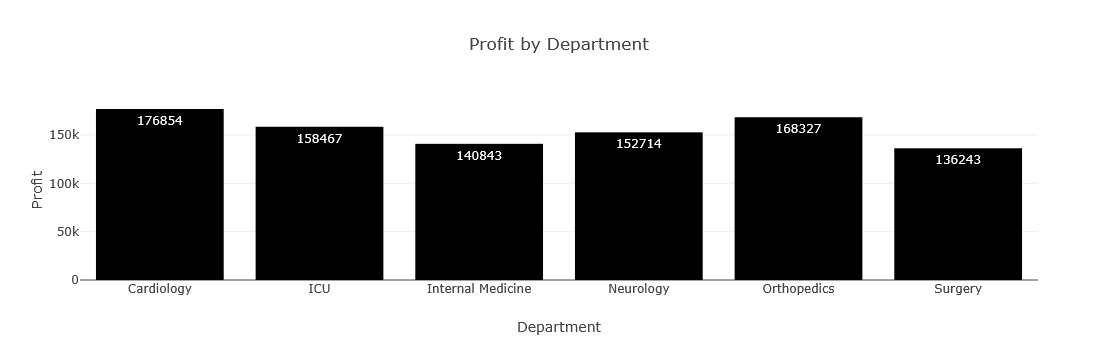

In [107]:
fig = px.bar(
    department_summary.reset_index(),
    x="department",
    y="profit",
    title="Profit by Department",
    text="profit"
)
fig.update_layout(
    xaxis_title="Department",
    yaxis_title="Profit"
)

fig.show()

In [108]:
score_df = department_summary.copy()
score_df["profit_score"] = (score_df["profit"]/score_df["profit"].max()) *100
score_df["alos_score"] = (1 -score_df["alos"]/score_df["alos"].max()) * 100
score_df["readmission_score"] = (1- score_df["readmission_rate"]/score_df["readmission_rate"].max()) * 100
score_df["mortality_score"] = ( 1 -score_df["mortality_rate"]/score_df["mortality_rate"].max()) * 100
print(score_df)


                   patients  revenue    cost      alos  readmission_rate  \
department                                                                 
Cardiology               96   511685  334831  7.895833          8.333333   
ICU                      81   411625  253158  7.530864          9.876543   
Internal Medicine        77   378904  238061  6.818182         10.389610   
Neurology                82   454884  302170  7.414634         13.414634   
Orthopedics              89   477438  309111  7.831461          3.370787   
Surgery                  75   391795  255552  7.746667         10.666667   

                   mortality_rate  profit  profit_score  alos_score  \
department                                                            
Cardiology               1.041667  176854    100.000000    0.000000   
ICU                      1.234568  158467     89.603289    4.622300   
Internal Medicine        2.597403  140843     79.638006   13.648357   
Neurology                1.219512  1

In [109]:
score_df["overall_score"] = (score_df["profit_score"]
    +
    score_df["alos_score"]
    +
    score_df["readmission_score"]
    +
    score_df["mortality_score"]
) / 4
score_df

,patients,revenue,cost,alos,readmission_rate,mortality_rate,profit,profit_score,alos_score,readmission_score,mortality_score,overall_score
department,,,,,,,,,,,,
Cardiology,96,511685,334831,7.895833,8.333333,1.041667,176854,100.000000,0.000000,37.878788,60.937500,49.704072
ICU,81,411625,253158,7.530864,9.876543,1.234568,158467,89.603289,4.622300,26.374860,53.703704,43.576038
Internal Medicine,77,378904,238061,6.818182,10.389610,2.597403,140843,79.638006,13.648357,22.550177,2.597403,29.608486
Neurology,82,454884,302170,7.414634,13.414634,1.219512,152714,86.350323,6.094343,0.000000,54.268293,36.678240
Orthopedics,89,477438,309111,7.831461,3.370787,1.123596,168327,95.178509,0.815274,74.872319,57.865169,57.182817
Surgery,75,391795,255552,7.746667,10.666667,2.666667,136243,77.036991,1.889182,20.484848,0.000000,24.852755


In [110]:
score_df = score_df.sort_values(
    "overall_score",
    ascending=False
)

score_df[
    [
        "profit_score",
        "alos_score",
        "readmission_score",
        "mortality_score",
        "overall_score"
    ]
]
score_df

,patients,revenue,cost,alos,readmission_rate,mortality_rate,profit,profit_score,alos_score,readmission_score,mortality_score,overall_score
department,,,,,,,,,,,,
Orthopedics,89,477438,309111,7.831461,3.370787,1.123596,168327,95.178509,0.815274,74.872319,57.865169,57.182817
Cardiology,96,511685,334831,7.895833,8.333333,1.041667,176854,100.000000,0.000000,37.878788,60.937500,49.704072
ICU,81,411625,253158,7.530864,9.876543,1.234568,158467,89.603289,4.622300,26.374860,53.703704,43.576038
Neurology,82,454884,302170,7.414634,13.414634,1.219512,152714,86.350323,6.094343,0.000000,54.268293,36.678240
Internal Medicine,77,378904,238061,6.818182,10.389610,2.597403,140843,79.638006,13.648357,22.550177,2.597403,29.608486
Surgery,75,391795,255552,7.746667,10.666667,2.666667,136243,77.036991,1.889182,20.484848,0.000000,24.852755


In [111]:
score_df["weighted_score"] = (
    score_df["mortality_score"] * 0.40
    +
    score_df["readmission_score"] * 0.30
    +
    score_df["profit_score"] * 0.20
    +
    score_df["alos_score"] * 0.10
)
print(score_df["weighted_score"])

department
Orthopedics          64.724992
Cardiology           55.738636
ICU                  47.776827
Neurology            39.586816
Internal Medicine    25.096451
Surgery              21.741771
Name: weighted_score, dtype: float64


In [112]:
score_df = score_df.sort_values(
    by="weighted_score",
    ascending=False
)

score_df["new_rank"] = range(
    1,len(score_df)+1
)

score_df[
    [
        "new_rank",
        "weighted_score",
        "profit_score",
        "alos_score",
        "readmission_score",
        "mortality_score"
    ]
]


,new_rank,weighted_score,profit_score,alos_score,readmission_score,mortality_score
department,,,,,,
Orthopedics,1,64.724992,95.178509,0.815274,74.872319,57.865169
Cardiology,2,55.738636,100.000000,0.000000,37.878788,60.937500
ICU,3,47.776827,89.603289,4.622300,26.374860,53.703704
Neurology,4,39.586816,86.350323,6.094343,0.000000,54.268293
Internal Medicine,5,25.096451,79.638006,13.648357,22.550177,2.597403
Surgery,6,21.741771,77.036991,1.889182,20.484848,0.000000


In [114]:
import streamlit as st
import pandas as pd

# --- بخش تنظیم وزن‌ها توسط کاربر ---
st.sidebar.header("تنظیم وزن‌های اهمیت (۰ تا ۱۰)")
st.sidebar.markdown("با استفاده از اسلایدرهای زیر، میزان اهمیت هر معیار را مشخص کنید. مجموع وزن‌ها به صورت خودکار برابر با ۱ خواهد شد.")

# 1. دریافت امتیاز اهمیت از کاربر (استفاده از اسلایدرها)
# برای هر معیار، یک اسلایدر از 0 تا 10 ایجاد می‌کنیم.
# مقدار پیش‌فرض (default) برای هر کدام 2.5 است.
w_profit = st.sidebar.slider("اهمیت سود (Profit)", 0.0, 10.0, 2.5, key='profit_slider')
w_alos = st.sidebar.slider("اهمیت مدت بستری (ALOS)", 0.0, 10.0, 2.5, key='alos_slider')
w_readmission = st.sidebar.slider("اهمیت بستری مجدد (Readmission)", 0.0, 10.0, 2.5, key='readmission_slider')
w_mortality = st.sidebar.slider("اهمیت مرگ‌ومیر (Mortality)", 0.0, 10.0, 2.5, key='mortality_slider')

# 2. محاسبه مجموع امتیازهای وارد شده توسط کاربر
total_weight_input = w_profit + w_alos + w_readmission + w_mortality

# 3. محاسبه وزن‌های نهایی نرمال‌شده
# برای اطمینان از اینکه مجموع وزن‌ها دقیقاً ۱ شود، هر امتیاز را بر مجموع کل تقسیم می‌کنیم.
if total_weight_input > 0:
    # محاسبه وزن نهایی هر معیار
    profit_weight = w_profit / total_weight_input
    alos_weight = w_alos / total_weight_input
    readmission_weight = w_readmission / total_weight_input
    mortality_weight = w_mortality / total_weight_input
else:
    # اگر کاربر همه اسلایدرها را روی صفر قرار دهد، وزن‌ها را به صورت مساوی تقسیم می‌کنیم
    # (یا می‌توانید یک پیام خطا نمایش دهید یا مقادیر پیش‌فرض را نگه دارید).
    # در اینجا، به صورت مساوی تقسیم می‌شود تا از تقسیم بر صفر جلوگیری شود.
    profit_weight = 0.25
    alos_weight = 0.25
    readmission_weight = 0.25
    mortality_weight = 0.25

# 4. نمایش وزن‌های نهایی محاسبه شده به کاربر در نوار کناری
st.sidebar.markdown("---") # یک خط جداکننده
st.sidebar.write("### وزن‌های نهایی (مجموع ۱.۰):")
st.sidebar.write(f"- **سود:** {profit_weight:.3f}")
st.sidebar.write(f"- **مدت بستری:** {alos_weight:.3f}")
st.sidebar.write(f"- **بستری مجدد:** {readmission_weight:.3f}")
st.sidebar.write(f"- **مرگ‌ومیر:** {mortality_weight:.3f}")
st.sidebar.markdown(f"**مجموع:** {profit_weight + alos_weight + readmission_weight + mortality_weight:.3f}")


# --- بخش استفاده از وزن‌های محاسبه شده برای رتبه‌بندی (مثال) ---
# فرض می‌کنیم 'score_df' یک DataFrame پانداز است که قبلاً با امتیازات محاسبه شده پر شده است.
# مثال:
data = {
    'profit_score': [95.18, 100.00, 89.60, 86.35, 79.64, 77.04],
    'alos_score': [0.82, 0.00, 4.62, 6.09, 13.65, 1.89],
    'readmission_score': [74.87, 37.88, 26.37, 0.00, 22.55, 20.48],
    'mortality_score': [57.87, 60.94, 53.70, 54.27, 2.60, 0.00],
}
department_names = ["Orthopedics", "Cardiology", "ICU", "Neurology", "Internal Medicine", "Surgery"]
score_df = pd.DataFrame(data, index=department_names)


# محاسبه ستون weighted_score با استفاده از وزن‌های محاسبه شده
score_df["weighted_score"] = (
    score_df["profit_score"] * profit_weight +
    score_df["alos_score"] * alos_weight +
    score_df["readmission_score"] * readmission_weight +
    score_df["mortality_score"] * mortality_weight
)

# مرتب‌سازی دیتافریم بر اساس weighted_score برای نمایش رتبه‌بندی
ranked_df = score_df.sort_values(by="weighted_score", ascending=False)

# نمایش نتایج در صفحه اصلی اپلیکیشن Streamlit
st.header("تحلیل عملکرد دپارتمان‌ها با امتیاز وزنی")

st.write("جدول رتبه‌بندی دپارتمان‌ها بر اساس امتیاز وزنی:")
# نمایش ستون‌های امتیاز و امتیاز نهایی وزنی با فرمت‌دهی دو رقم اعشار
st.dataframe(ranked_df[['profit_score', 'alos_score', 'readmission_score', 'mortality_score', 'weighted_score']].style.format("{:.2f}"))

st.write("### برترین دپارتمان‌ها:")
# نمایش 3 دپارتمان برتر
top_departments = ranked_df.head(3)
st.dataframe(top_departments.style.format("{:.2f}"))


2026-06-10 10:13:58.527 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 10:13:58.746 
  command:

    streamlit run C:\Users\ALLAH\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-10 10:13:58.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 10:13:58.752 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 10:13:58.754 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 10:13:58.756 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 10:13:58.761 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 10:13:58.762 Thread 'MainThread': mi

DeltaGenerator()

In [115]:
score_df.iloc[0]

profit_score         95.180
alos_score            0.820
readmission_score    74.870
mortality_score      57.870
weighted_score       57.185
Name: Orthopedics, dtype: float64

In [116]:
score_df.iloc[-1]

profit_score         77.0400
alos_score            1.8900
readmission_score    20.4800
mortality_score       0.0000
weighted_score       24.8525
Name: Surgery, dtype: float64

In [117]:
score_df.head(3)

,profit_score,alos_score,readmission_score,mortality_score,weighted_score
Orthopedics,95.18,0.82,74.87,57.87,57.1850
Cardiology,100.00,0.00,37.88,60.94,49.7050
ICU,89.60,4.62,26.37,53.70,43.5725


In [118]:
score_df.tail(3)

,profit_score,alos_score,readmission_score,mortality_score,weighted_score
Neurology,86.35,6.09,0.00,54.27,36.6775
Internal Medicine,79.64,13.65,22.55,2.60,29.6100
Surgery,77.04,1.89,20.48,0.00,24.8525


In [126]:
print(score_df.reset_index().columns)
score_df.index.name = "department"
score_df_reset = score_df.reset_index()
print("==================================================================")
print(score_df_reset.columns)


Index(['department', 'profit_score', 'alos_score', 'readmission_score',
       'mortality_score', 'weighted_score'],
      dtype='object')
Index(['department', 'profit_score', 'alos_score', 'readmission_score',
       'mortality_score', 'weighted_score'],
      dtype='object')


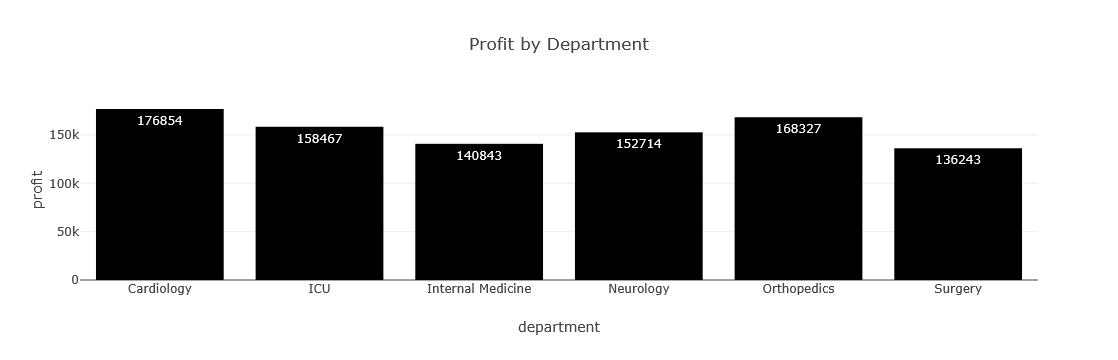

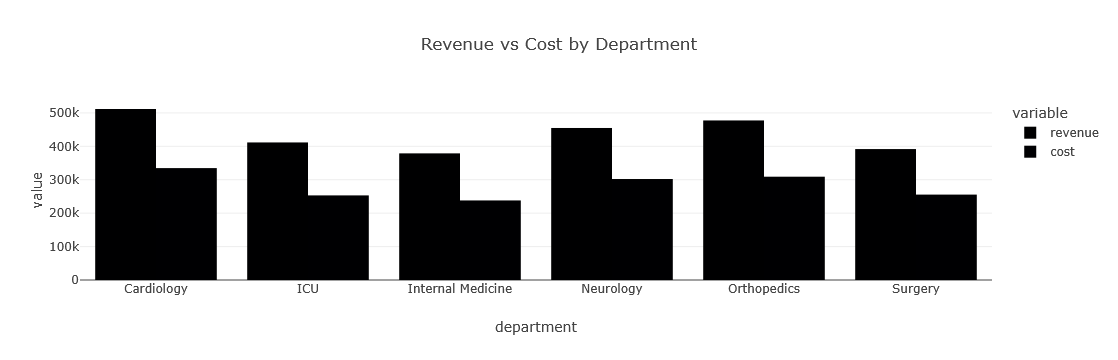

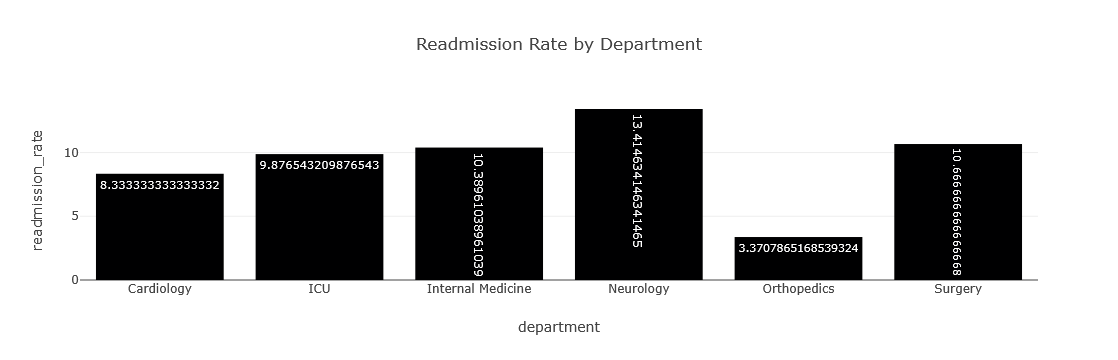

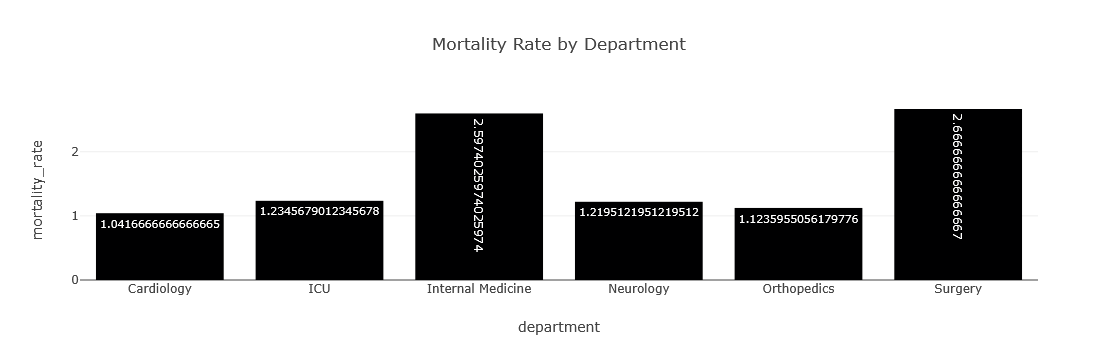

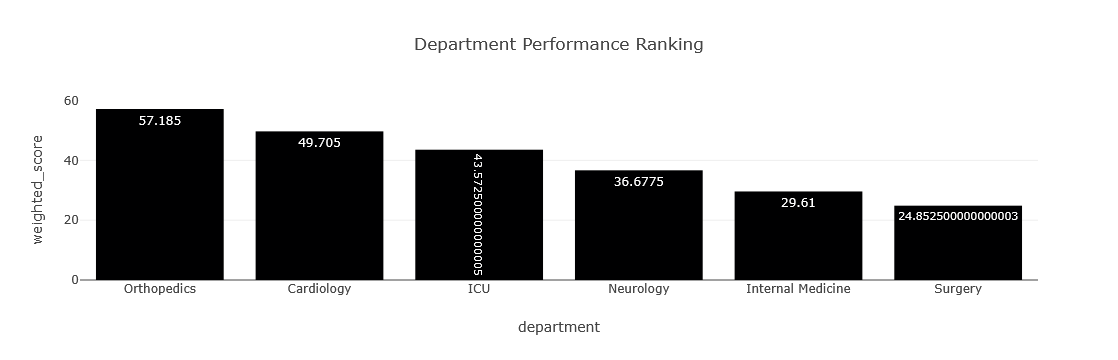

In [127]:

fig = px.bar(
    department_summary.reset_index(),
    x="department",
    y="profit",
    text="profit",
    title="Profit by Department"
)

fig.show()

dept_financial = department_summary.reset_index()

fig = px.bar(
    dept_financial,
    x="department",
    y=["revenue","cost"],
    barmode="group",
    title="Revenue vs Cost by Department"
)

fig.show()


fig = px.bar(
    department_summary.reset_index(),
    x="department",
    y="readmission_rate",
    text="readmission_rate",
    title="Readmission Rate by Department"
)

fig.show()


fig = px.bar(
    department_summary.reset_index(),
    x="department",
    y="mortality_rate",
    text="mortality_rate",
    title="Mortality Rate by Department"
)

fig.show()


fig = px.bar(
    score_df.reset_index(),
    x="department",
    y="weighted_score",
    text="weighted_score",
    title="Department Performance Ranking"
)

fig.show()


In [128]:
if mortality_rate_fill > 2:
    print("🔴 High Mortality Alert")
else:
    print("🟢 Mortality Rate is within acceptable range")

🟢 Mortality Rate is within acceptable range


In [129]:
if readmission_rate_fill > 10:
    print("🟠 High Readmission Alert")
else:
    print("🟢 Readmission Rate is within acceptable range")

🟢 Readmission Rate is within acceptable range


In [130]:
if alos_fill > 8:
    print("🟠 Length of Stay is High")
else:
    print("🟢 Length of Stay is within acceptable range")

🟢 Length of Stay is within acceptable range


In [131]:
doctor_summary = (
    df.groupby("doctor")
      .agg({
          "patient_id":"count",
          "revenue":"sum",
          "cost":"sum",
          "length_of_stay":"mean",
          "readmission_flag":"mean",
          "death_flag":"mean",
          "satisfaction_score":"mean"
      })
)

doctor_summary = doctor_summary.rename(
    columns={
        "patient_id":"patients",
        "length_of_stay":"alos",
        "readmission_flag":"readmission_rate",
        "death_flag":"mortality_rate",
        "satisfaction_score":"satisfaction"
    }
)

doctor_summary["profit"] = (
    doctor_summary["revenue"]
    -
    doctor_summary["cost"]
)

doctor_summary["readmission_rate"] *= 100
doctor_summary["mortality_rate"] *= 100

doctor_summary.sort_values(
    "profit",
    ascending=False
).head(10)


,patients,revenue,cost,alos,readmission_rate,mortality_rate,satisfaction,profit
doctor,,,,,,,,
Dr_16,28,151227,90907,8.428571,10.714286,7.142857,2.960714,60320
Dr_20,27,164523,106773,6.333333,11.111111,0.000000,3.122222,57750
Dr_8,24,126766,70902,7.041667,8.333333,4.166667,2.966667,55864
Dr_19,31,154941,99794,8.419355,6.451613,0.000000,3.151613,55147
Dr_1,26,143112,90019,6.230769,11.538462,0.000000,2.707692,53093
Dr_5,21,129225,76723,6.238095,4.761905,4.761905,2.947619,52502
Dr_3,31,141236,90777,8.193548,12.903226,3.225806,2.829032,50459
Dr_15,25,134003,84356,6.840000,24.000000,0.000000,3.284000,49647
Dr_10,28,143165,93601,9.321429,3.571429,0.000000,3.189286,49564


In [133]:
doctor_filtered = doctor_summary[
    doctor_summary["patients"] >= 20
].copy()

doctor_filtered["profit_score"] = (
    doctor_filtered["profit"]
    /
    doctor_filtered["profit"].max()
) * 100

doctor_filtered["satisfaction_score_norm"] = (
    doctor_filtered["satisfaction"]
    /
    doctor_filtered["satisfaction"].max()
) * 100

doctor_filtered["readmission_score"] = (
    1 -
    doctor_filtered["readmission_rate"]
    /
    doctor_filtered["readmission_rate"].max()
) * 100

doctor_filtered["mortality_score"] = (
    1 -
    doctor_filtered["mortality_rate"]
    /
    doctor_filtered["mortality_rate"].max()
) * 100


In [134]:
st.sidebar.header(
    "Doctor Ranking Weights"
)

w_profit = st.sidebar.slider(
    "Profit Importance",
    0.0,
    10.0,
    2.5
)

w_satisfaction = st.sidebar.slider(
    "Patient Satisfaction Importance",
    0.0,
    10.0,
    2.5
)

w_readmission = st.sidebar.slider(
    "Readmission Importance",
    0.0,
    10.0,
    2.5
)

w_mortality = st.sidebar.slider(
    "Mortality Importance",
    0.0,
    10.0,
    2.5
)

2026-06-10 11:11:17.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 11:11:17.274 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 11:11:17.277 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 11:11:17.279 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 11:11:17.281 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 11:11:17.284 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 11:11:17.285 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-10 11:11:17.287 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [135]:
total_weight = (
    w_profit
    + w_satisfaction
    + w_readmission
    + w_mortality
)

profit_weight = (
    w_profit / total_weight
)

satisfaction_weight = (
    w_satisfaction / total_weight
)

readmission_weight = (
    w_readmission / total_weight
)

mortality_weight = (
    w_mortality / total_weight
)

In [136]:
doctor_filtered["profit_score"]

doctor_filtered["satisfaction_score_norm"]

doctor_filtered["readmission_score"]

doctor_filtered["mortality_score"]

doctor
Dr_1     100.000000
Dr_10    100.000000
Dr_12     39.130435
Dr_13    100.000000
Dr_14    100.000000
Dr_15    100.000000
Dr_16      0.000000
Dr_17    100.000000
Dr_18    100.000000
Dr_19    100.000000
Dr_2     100.000000
Dr_20    100.000000
Dr_3      54.838710
Dr_5      33.333333
Dr_6     100.000000
Dr_7      48.148148
Dr_8      41.666667
Dr_9     100.000000
Name: mortality_score, dtype: float64

In [137]:
doctor_filtered["overall_score"] = (
    doctor_filtered["profit_score"]
    * profit_weight

    +

    doctor_filtered["satisfaction_score_norm"]
    * satisfaction_weight

    +

    doctor_filtered["readmission_score"]
    * readmission_weight

    +

    doctor_filtered["mortality_score"]
    * mortality_weight
)

In [138]:
doctor_filtered = doctor_filtered.sort_values(
    by="overall_score",
    ascending=False
)

doctor_filtered["rank"] = range(
    1,
    len(doctor_filtered)+1
)

In [139]:
doctor_filtered[
    [
        "rank",
        "overall_score",
        "profit",
        "satisfaction",
        "readmission_rate",
        "mortality_rate"
    ]
]

,rank,overall_score,profit,satisfaction,readmission_rate,mortality_rate
doctor,,,,,,
Dr_10,1,90.272501,49564,3.189286,3.571429,0.000000
Dr_19,2,89.309212,55147,3.151613,6.451613,0.000000
Dr_13,3,89.272627,46011,3.253571,3.571429,0.000000
Dr_17,4,87.387360,47735,2.900000,3.571429,0.000000
Dr_20,5,85.318290,57750,3.122222,11.111111,0.000000
Dr_18,6,82.489454,46555,2.975000,8.333333,0.000000
Dr_6,7,81.973121,47319,2.913043,8.695652,0.000000
Dr_14,8,81.345585,47579,2.813043,8.695652,0.000000
Dr_1,9,79.894996,53093,2.707692,11.538462,0.000000


In [140]:
best_doctor = doctor_filtered.index[0]

worst_doctor = doctor_filtered.index[-1]

print(
    f"Best Doctor: {best_doctor}"
)

print(
    f"Worst Doctor: {worst_doctor}"
)

Best Doctor: Dr_10
Worst Doctor: Dr_16


In [142]:
# ==========================================
# Insurance Analytics
# ==========================================

insurance_summary = (
    df.groupby("insurance_type")
      .agg({
          "patient_id":"count",
          "revenue":"sum",
          "cost":"sum",
          "satisfaction_score":"mean",
          "length_of_stay":"mean",
          "readmission_flag":"mean",
          "death_flag":"mean"
      })
)

insurance_summary = insurance_summary.rename(
    columns={
        "patient_id":"patients",
        "satisfaction_score":"satisfaction",
        "length_of_stay":"alos",
        "readmission_flag":"readmission_rate",
        "death_flag":"mortality_rate"
    }
)

insurance_summary["profit"] = (
    insurance_summary["revenue"]
    -
    insurance_summary["cost"]
)

insurance_summary["readmission_rate"] *= 100
insurance_summary["mortality_rate"] *= 100

insurance_summary


,patients,revenue,cost,satisfaction,alos,readmission_rate,mortality_rate,profit
insurance_type,,,,,,,,
Armed Forces,115,545747,331490,3.088696,7.582609,8.695652,2.608696,214257
Private,121,662246,424502,2.968595,7.768595,8.264463,0.826446,237744
Social Security,133,689201,455371,2.936842,7.218045,9.774436,0.751880,233830


In [143]:
insurance_summary.sort_values(
    by="profit",
    ascending=False
)


,patients,revenue,cost,satisfaction,alos,readmission_rate,mortality_rate,profit
insurance_type,,,,,,,,
Private,121,662246,424502,2.968595,7.768595,8.264463,0.826446,237744
Social Security,133,689201,455371,2.936842,7.218045,9.774436,0.751880,233830
Armed Forces,115,545747,331490,3.088696,7.582609,8.695652,2.608696,214257


In [144]:
insurance_summary.sort_values(
    by="patients",
    ascending=False
)


,patients,revenue,cost,satisfaction,alos,readmission_rate,mortality_rate,profit
insurance_type,,,,,,,,
Social Security,133,689201,455371,2.936842,7.218045,9.774436,0.751880,233830
Private,121,662246,424502,2.968595,7.768595,8.264463,0.826446,237744
Armed Forces,115,545747,331490,3.088696,7.582609,8.695652,2.608696,214257


In [145]:
insurance_summary.sort_values(
    by="satisfaction",
    ascending=False
)


,patients,revenue,cost,satisfaction,alos,readmission_rate,mortality_rate,profit
insurance_type,,,,,,,,
Armed Forces,115,545747,331490,3.088696,7.582609,8.695652,2.608696,214257
Private,121,662246,424502,2.968595,7.768595,8.264463,0.826446,237744
Social Security,133,689201,455371,2.936842,7.218045,9.774436,0.751880,233830


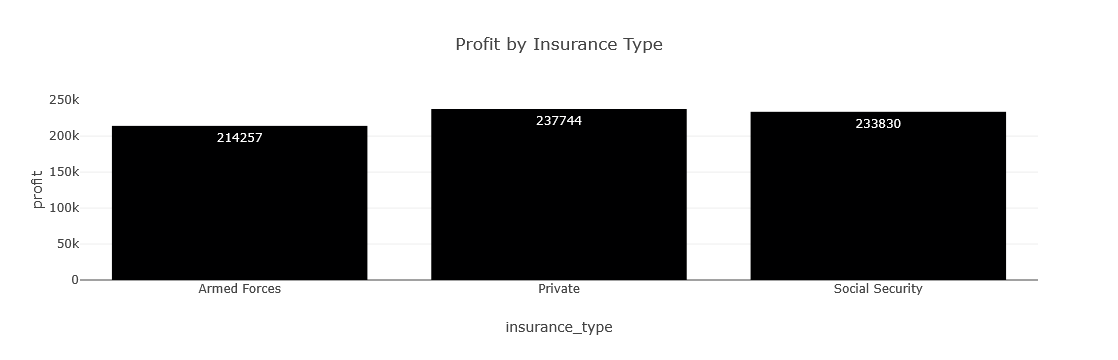

In [146]:
fig = px.bar(
    insurance_summary.reset_index(),
    x="insurance_type",
    y="profit",
    text="profit",
    title="Profit by Insurance Type"
)

fig.show()


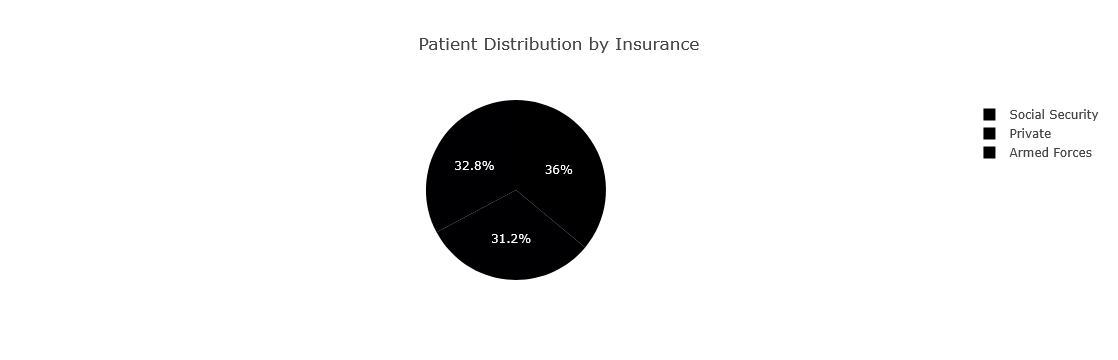

In [147]:
fig = px.pie(
    insurance_summary.reset_index(),
    names="insurance_type",
    values="patients",
    title="Patient Distribution by Insurance"
)

fig.show()


In [148]:
#تعداد بیماران ماهانه

monthly_patients = (
    df.groupby(
        df["admission_date"].dt.to_period("M")
    )
    .size()
    .reset_index(name="patients")
)

monthly_patients

,admission_date,patients
0,2025-01,47
1,2025-02,39
2,2025-03,51
3,2025-04,42
4,2025-05,38
5,2025-06,30
6,2025-07,50
7,2025-08,45
8,2025-09,37
9,2025-10,38


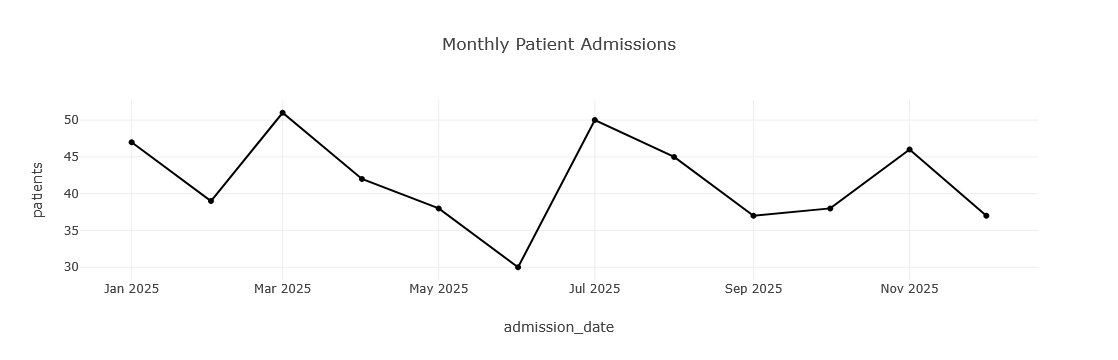

In [149]:
#نمودار پذیرش ماهانه

monthly_patients["admission_date"] = (
    monthly_patients["admission_date"]
    .astype(str)
)

fig = px.line(
    monthly_patients,
    x="admission_date",
    y="patients",
    markers=True,
    title="Monthly Patient Admissions"
)

fig.show()

In [150]:
#درآمد ماهانه

monthly_revenue = (
    df.groupby(
        df["admission_date"].dt.to_period("M")
    )["revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,admission_date,revenue
0,2025-01,238184
1,2025-02,200249
2,2025-03,279068
3,2025-04,204639
4,2025-05,221222
5,2025-06,148373
6,2025-07,282400
7,2025-08,239464
8,2025-09,208454
9,2025-10,196657


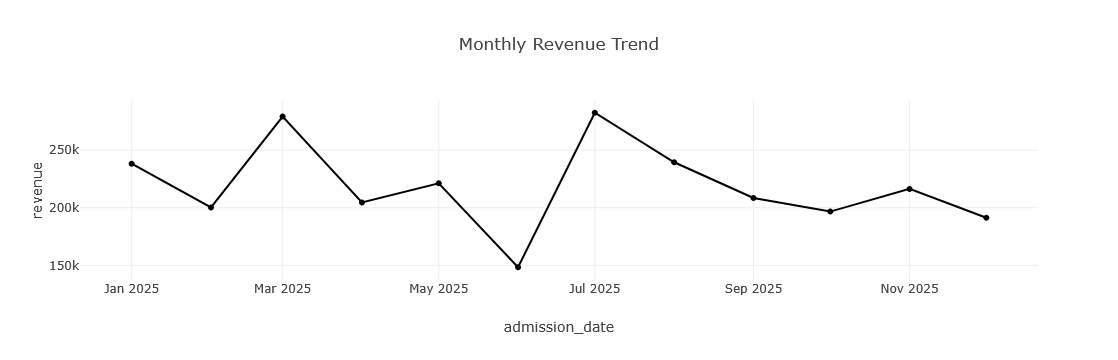

In [151]:
#نمودار درآمد ماهانه

monthly_revenue["admission_date"] = (
    monthly_revenue["admission_date"]
    .astype(str)
)

fig = px.line(
    monthly_revenue,
    x="admission_date",
    y="revenue",
    markers=True,
    title="Monthly Revenue Trend"
)

fig.show()

In [152]:
#هزینه ماهانه

monthly_cost = (
    df.groupby(
        df["admission_date"].dt.to_period("M")
    )["cost"]
    .sum()
    .reset_index()
)

monthly_cost

,admission_date,cost
0,2025-01,161858
1,2025-02,129728
2,2025-03,186512
3,2025-04,131948
4,2025-05,140611
5,2025-06,95457
6,2025-07,188556
7,2025-08,148393
8,2025-09,132587
9,2025-10,120684


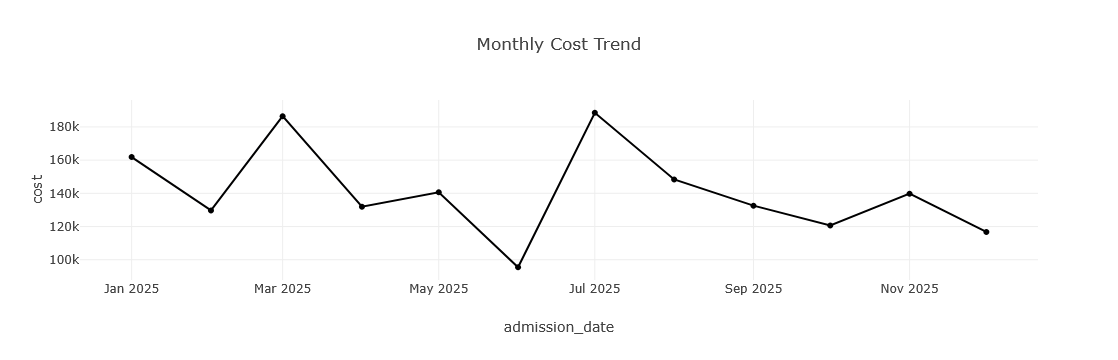

In [153]:
monthly_cost["admission_date"] = (
    monthly_cost["admission_date"]
    .astype(str)
)

fig = px.line(
    monthly_cost,
    x="admission_date",
    y="cost",
    markers=True,
    title="Monthly Cost Trend"
)

fig.show()

In [154]:
#سود ماهانه

monthly_profit = (
    df.groupby(
        df["admission_date"].dt.to_period("M")
    )
    .agg(
        revenue=("revenue","sum"),
        cost=("cost","sum")
    )
    .reset_index()
)

monthly_profit["profit"] = (
    monthly_profit["revenue"]
    -
    monthly_profit["cost"]
)

monthly_profit

,admission_date,revenue,cost,profit
0,2025-01,238184,161858,76326
1,2025-02,200249,129728,70521
2,2025-03,279068,186512,92556
3,2025-04,204639,131948,72691
4,2025-05,221222,140611,80611
5,2025-06,148373,95457,52916
6,2025-07,282400,188556,93844
7,2025-08,239464,148393,91071
8,2025-09,208454,132587,75867
9,2025-10,196657,120684,75973


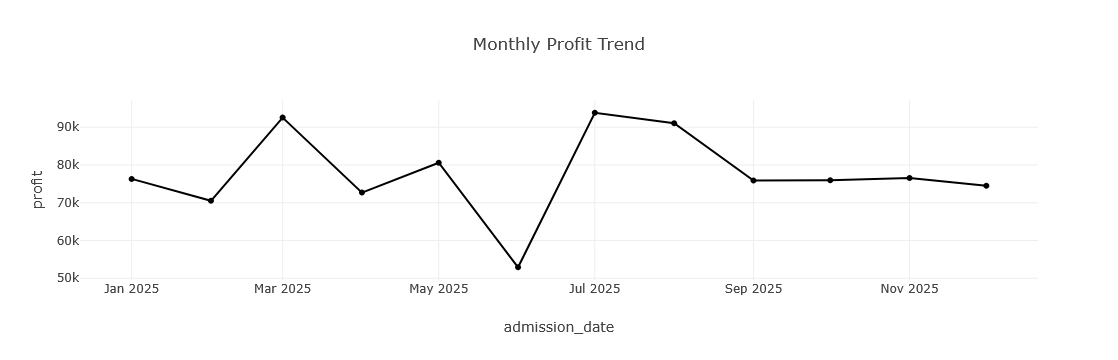

In [155]:
#نمودار سود ماهانه

monthly_profit["admission_date"] = (
    monthly_profit["admission_date"]
    .astype(str)
)

fig = px.line(
    monthly_profit,
    x="admission_date",
    y="profit",
    markers=True,
    title="Monthly Profit Trend"
)

fig.show()

In [156]:
#روند بستری مجدد

monthly_readmission = (
    df.groupby(
        df["admission_date"].dt.to_period("M")
    )["readmission_flag"]
    .mean()
    .reset_index()
)

monthly_readmission["readmission_flag"] *= 100

monthly_readmission

,admission_date,readmission_flag
0,2025-01,4.255319
1,2025-02,12.820513
2,2025-03,1.960784
3,2025-04,16.666667
4,2025-05,7.894737
5,2025-06,6.666667
6,2025-07,12.000000
7,2025-08,11.111111
8,2025-09,13.513514
9,2025-10,5.263158


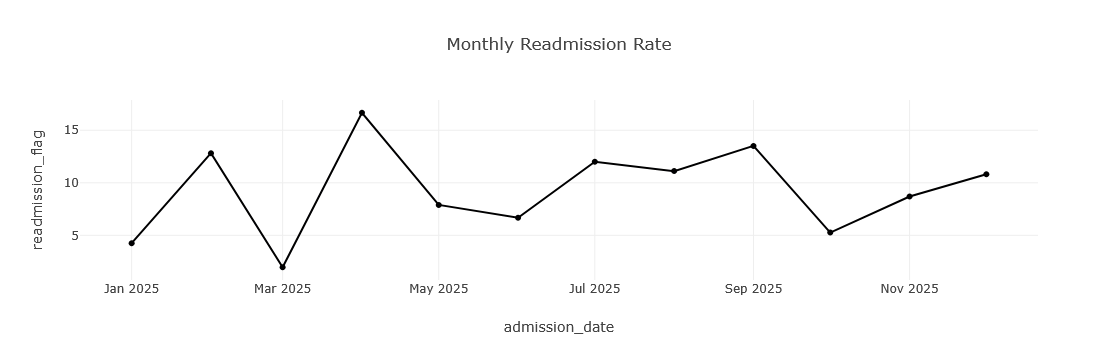

In [157]:
monthly_readmission["admission_date"] = (
    monthly_readmission["admission_date"]
    .astype(str)
)

fig = px.line(
    monthly_readmission,
    x="admission_date",
    y="readmission_flag",
    markers=True,
    title="Monthly Readmission Rate"
)

fig.show()

In [158]:
#روند مرگ‌ومیر

monthly_mortality = (
    df.groupby(
        df["admission_date"].dt.to_period("M")
    )["death_flag"]
    .mean()
    .reset_index()
)

monthly_mortality["death_flag"] *= 100


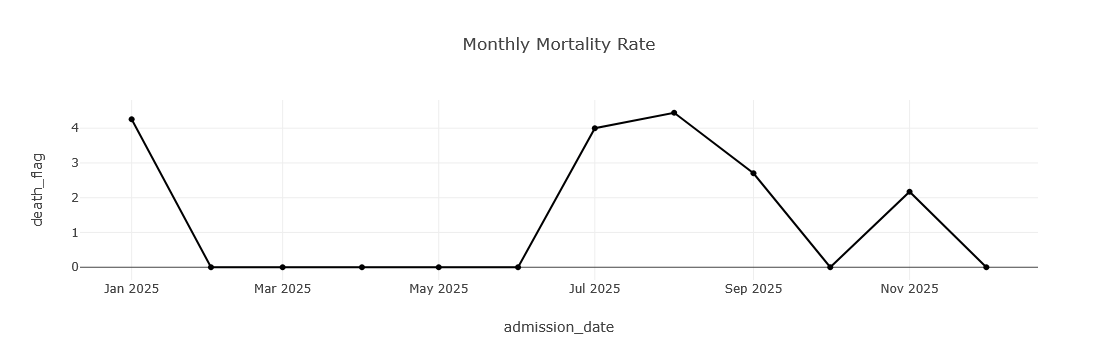

In [159]:
monthly_mortality["admission_date"] = (
    monthly_mortality["admission_date"]
    .astype(str)
)

fig = px.line(
    monthly_mortality,
    x="admission_date",
    y="death_flag",
    markers=True,
    title="Monthly Mortality Rate"
)

fig.show()

In [160]:
#روند رضایت بیماران

monthly_satisfaction = (
    df.groupby(
        df["admission_date"].dt.to_period("M")
    )["satisfaction_score"]
    .mean()
    .reset_index()
)

monthly_satisfaction


,admission_date,satisfaction_score
0,2025-01,3.059574
1,2025-02,2.966667
2,2025-03,2.990196
3,2025-04,3.152381
4,2025-05,3.431579
5,2025-06,2.980000
6,2025-07,2.886000
7,2025-08,3.140000
8,2025-09,2.556757
9,2025-10,3.205263


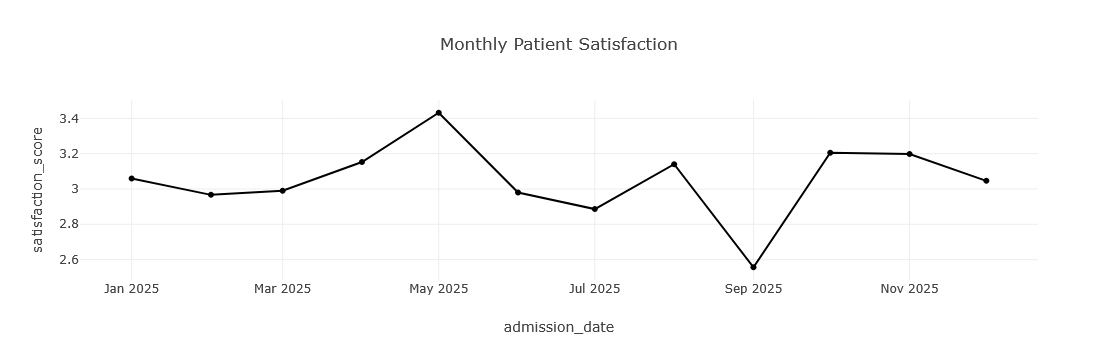

In [161]:
monthly_satisfaction["admission_date"] = (
    monthly_satisfaction["admission_date"]
    .astype(str)
)

fig = px.line(
    monthly_satisfaction,
    x="admission_date",
    y="satisfaction_score",
    markers=True,
    title="Monthly Patient Satisfaction"
)

fig.show()